# Exploratory Data Analysis: Antminer L3+ Telemetry

This notebook performs EDA on 55 minutes of real telemetry from an Antminer L3+ (Litecoin/Scrypt ASIC miner) polled every 5 seconds via cgminer's API. The dataset represents **healthy, stable operation** and will serve as the baseline for training two anomaly detection models:

1. **Isolation Forest (IF)** — a tree-based model that scores each reading independently by how easily it can be isolated from the rest of the data.
2. **LSTM Autoencoder** — a sequence model that learns temporal patterns and flags readings whose reconstruction error exceeds a learned threshold.

Both models dynamically select features from whatever numeric fields appear in the readings dictionary (see `isolation_forest.py:33` and `lstm_autoencoder.py:104`). The set of collected features is defined by the miner preset (`preset_registry.py`, `antminer_l3` preset). Our job here is to:
- Remove columns that carry no information (zero variance)
- Identify which remaining features the models will actually use
- Characterize distributions, correlations, and temporal behavior
- Document what “normal” looks like so we can evaluate anomaly detection performance later

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 5)

---
## 1. Data Loading and Cleaning

We load the raw telemetry export, parse timestamps, and drop columns with zero variance. The raw dataset has 667 rows × 219 columns. Most columns are pool-level metadata (pool0–pool4 duplicates), string fields, or hardware counters that never change during this capture window.

In [2]:
EXCEL_PATH = '../miner_data_20260501_190451.xlsx'

df_raw = pd.read_excel(EXCEL_PATH, sheet_name='Miner Data')
print(f'Raw shape: {df_raw.shape}')
print(f'Time range: {df_raw["timestamp"].iloc[0]} to {df_raw["timestamp"].iloc[-1]}')

Raw shape: (667, 219)
Time range: 2026-05-01 18:09:08.512574 to 2026-05-01 19:04:41.595894


In [3]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw = df_raw.sort_values('timestamp').reset_index(drop=True)

elapsed = (df_raw['timestamp'].iloc[-1] - df_raw['timestamp'].iloc[0]).total_seconds()
print(f'Duration: {elapsed:.0f}s ({elapsed/60:.1f} min)')
print(f'Mean poll interval: {elapsed / (len(df_raw)-1):.2f}s')

Duration: 3333s (55.6 min)
Mean poll interval: 5.00s


In [4]:
# Keep only numeric columns for variance analysis
df_numeric = df_raw.select_dtypes(include=[np.number])
print(f'Numeric columns: {df_numeric.shape[1]} of {df_raw.shape[1]}')

# Identify zero-variance columns
variances = df_numeric.var()
zero_var_cols = variances[variances == 0].index.tolist()
print(f'\nZero-variance columns ({len(zero_var_cols)}):')
for col in sorted(zero_var_cols):
    print(f'  {col} = {df_numeric[col].iloc[0]}')

Numeric columns: 183 of 219

Zero-variance columns (103):
  Difficulty Stale = 0
  Found Blocks = 0
  Last Share Difficulty = 32768.0
  POOL = 0.0
  Pool Stale% = 0
  Priority = 0.0
  Quota = 1.0
  Remote Failures = 0
  Stale = 0
  chain_acn1 = 72
  chain_acn2 = 72
  chain_acn3 = 72
  chain_acn4 = 67
  chain_hw4 = 0
  chain_power = 422
  chain_power1 = 105.5
  chain_power2 = 105.5
  chain_power3 = 105.5
  chain_power4 = 105.5
  frequency = 200
  frequency1 = 200
  frequency2 = 200
  frequency3 = 200
  frequency4 = 200
  miner_count = 4
  pool0_Difficulty Rejected = nan
  pool0_Difficulty Stale = nan
  pool0_Get Failures = nan
  pool0_POOL = nan
  pool0_Pool Rejected% = nan
  pool0_Pool Stale% = nan
  pool0_Priority = nan
  pool0_Quota = nan
  pool0_Rejected = nan
  pool0_Remote Failures = nan
  pool0_Stale = nan
  pool1_Accepted = nan
  pool1_Best Share = nan
  pool1_Diff1 Shares = nan
  pool1_Difficulty Accepted = nan
  pool1_Difficulty Rejected = nan
  pool1_Difficulty Stale = nan
  

In [5]:
df_clean = df_numeric.drop(columns=zero_var_cols)
print(f'After dropping zero-variance: {df_clean.shape[1]} numeric columns remain')

After dropping zero-variance: 80 numeric columns remain


### Why constant features are harmful to anomaly detection

A feature with zero variance across all training samples carries **no discriminative information**. For anomaly detection specifically:

- **Isolation Forest**: splits are chosen at random from all features. A constant feature wastes split opportunities — every split on it produces two groups with the same data distribution, adding tree depth without improving isolation. This dilutes the effective contamination signal from informative features and inflates path lengths uniformly, making anomalies harder to separate.

- **LSTM Autoencoder**: a constant feature is trivially reconstructed (the model learns to output the constant), contributing zero to reconstruction error during training. At inference, if the feature remains constant, it adds noise to the error denominator; if it suddenly changes (e.g., a voltage rail that was always 0.0 reporting a value), the model has no learned representation for that variation and may produce misleading error spikes.

- **StandardScaler** (used by both models): scaling a zero-variance column produces division by zero (or near-zero), resulting in NaN or extreme values that corrupt the entire feature matrix.

Removing constant features is a necessary preprocessing step, not optional.

---
## 2. Feature Selection

Both the Isolation Forest and LSTM Autoencoder dynamically select features from the readings dictionary at training time. The IF (`isolation_forest.py:33`) keeps all keys except `timestamp` and `_`-prefixed keys. The LSTM (`lstm_autoencoder.py:104`) keeps all keys except `timestamp`.

The set of features collected from the miner is defined by the `antminer_l3` preset in `preset_registry.py`. We now intersect the non-constant columns from our data with the preset feature list to determine exactly which features the models will train on.

In [6]:
# Features defined in the antminer_l3 preset (from preset_registry.py)
PRESET_FEATURES = [
    'GHS 5s', 'GHS av', 'Hardware Errors', 'Device Rejected%',
    'temp1', 'temp2', 'temp3', 'temp4',
    'temp2_1', 'temp2_2', 'temp2_3', 'temp2_4', 'temp_max',
    'fan1', 'fan2',
    'frequency', 'frequency1', 'frequency2', 'frequency3', 'frequency4',
    'chain_rate1', 'chain_rate2', 'chain_rate3', 'chain_rate4',
    'chain_acn1', 'chain_acn2', 'chain_acn3', 'chain_acn4',
    'chain_hw1', 'chain_hw2', 'chain_hw3', 'chain_hw4',
    'chain_power1', 'chain_power2', 'chain_power3', 'chain_power4', 'chain_power',
    'voltage1', 'voltage2', 'voltage3', 'voltage4',
    'Device Hardware%', 'no_matching_work', 'miner_count',
]

# Intersect with non-constant columns in our data
available = [f for f in PRESET_FEATURES if f in df_clean.columns]
dropped_constant = [f for f in PRESET_FEATURES if f not in df_clean.columns and f in df_numeric.columns]
missing = [f for f in PRESET_FEATURES if f not in df_numeric.columns]

print(f'Preset features available (non-constant): {len(available)}')
print(f'Preset features dropped (constant):       {len(dropped_constant)}')
print(f'Preset features not in data:              {len(missing)}')
print(f'\nDropped as constant: {dropped_constant}')

Preset features available (non-constant): 23
Preset features dropped (constant):       21
Preset features not in data:              0

Dropped as constant: ['temp2', 'frequency', 'frequency1', 'frequency2', 'frequency3', 'frequency4', 'chain_acn1', 'chain_acn2', 'chain_acn3', 'chain_acn4', 'chain_hw4', 'chain_power1', 'chain_power2', 'chain_power3', 'chain_power4', 'chain_power', 'voltage1', 'voltage2', 'voltage3', 'voltage4', 'miner_count']


In [7]:
# Final feature set for model training
SELECTED_FEATURES = available
df_features = df_clean[SELECTED_FEATURES].copy()
df_features.insert(0, 'timestamp', df_raw['timestamp'])
print(f'Feature matrix shape: {df_features.shape}')
print(f'\nSelected features ({len(SELECTED_FEATURES)}):')
for f in SELECTED_FEATURES:
    print(f'  {f}')

Feature matrix shape: (667, 24)

Selected features (23):
  GHS 5s
  GHS av
  Hardware Errors
  Device Rejected%
  temp1
  temp3
  temp4
  temp2_1
  temp2_2
  temp2_3
  temp2_4
  temp_max
  fan1
  fan2
  chain_rate1
  chain_rate2
  chain_rate3
  chain_rate4
  chain_hw1
  chain_hw2
  chain_hw3
  Device Hardware%
  no_matching_work


### Final Feature Set

The following features survive zero-variance filtering and are defined in the Antminer L3+ preset. These are exactly the features that the IF and LSTM will train on:

| Feature | Physical Meaning |
|---------|------------------|
| `GHS 5s` | Total hashrate averaged over the last 5 seconds (GH/s) |
| `GHS av` | Total hashrate averaged over the entire session (GH/s) |
| `Hardware Errors` | Cumulative count of hardware computation errors |
| `Device Rejected%` | Percentage of submitted shares rejected by the pool |
| `Device Hardware%` | Percentage of work results that are hardware errors |
| `temp1` | PCB inlet temperature, board 1 (°C) |
| `temp3` | PCB inlet temperature, board 3 (°C) |
| `temp4` | PCB inlet temperature, board 4 (°C) |
| `temp2_1` | Chip exhaust temperature, board 1 (°C) — hotter than PCB |
| `temp2_2` | Chip exhaust temperature, board 2 (°C) |
| `temp2_3` | Chip exhaust temperature, board 3 (°C) |
| `temp2_4` | Chip exhaust temperature, board 4 (°C) |
| `temp_max` | Maximum temperature across all sensors (°C) |
| `fan1` | Fan 1 speed (RPM) |
| `fan2` | Fan 2 speed (RPM) |
| `chain_rate1`–`chain_rate4` | Per-board hashrate (GH/s) |
| `chain_hw1`–`chain_hw3` | Per-board hardware error count |
| `no_matching_work` | Stale work submissions (pool sent new block before result returned) |

**Note:** `temp2` (PCB board 2) was constant at 39°C across all 667 readings and was dropped. `chain_hw4` was constant at 0. All frequency, voltage, chain_acn, chain_power, and miner_count fields were constant and dropped.

---
## 3. Distribution Analysis

For each selected feature, we plot a histogram with an overlaid KDE curve to understand the marginal distribution. This is important because the Isolation Forest assumes that anomalies are points in low-density regions of the feature space. Features with heavy skew, multiple modes, or long tails will naturally have more points in low-density regions, potentially inflating anomaly scores even during normal operation.

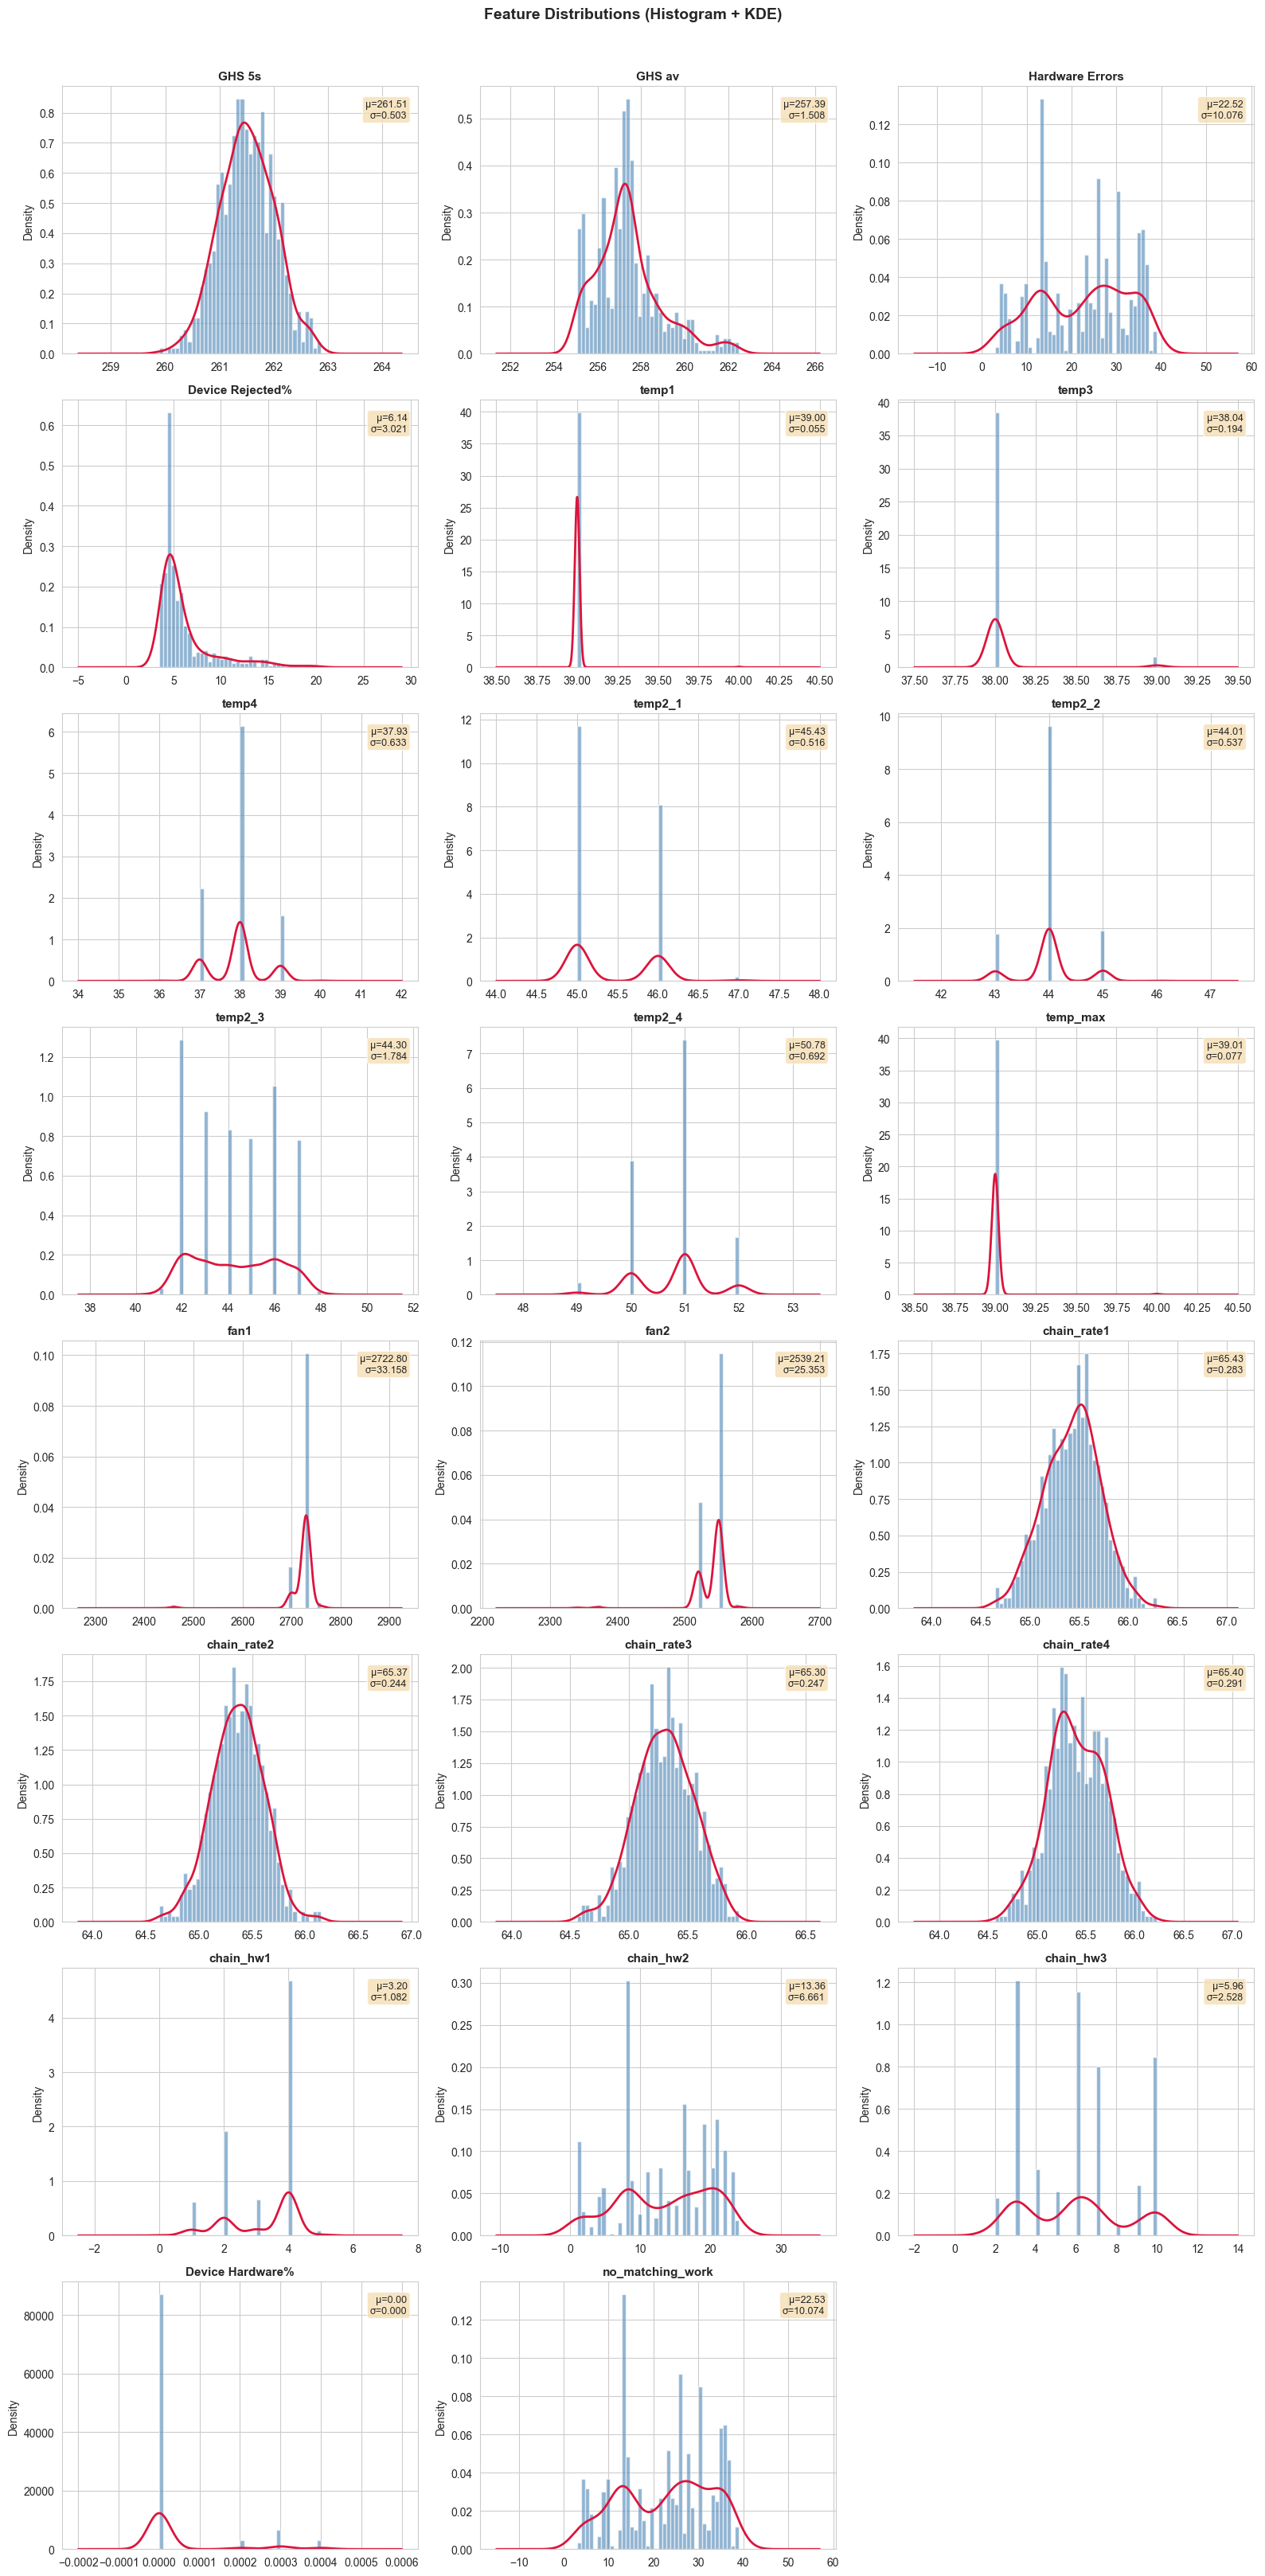

In [8]:
n_features = len(SELECTED_FEATURES)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(SELECTED_FEATURES):
    ax = axes[i]
    data = df_features[feat].dropna()
    mean_val = data.mean()
    std_val = data.std()
    
    ax.hist(data, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    
    if std_val > 0:
        try:
            data.plot.kde(ax=ax, color='crimson', linewidth=2)
        except Exception:
            pass
    
    ax.set_title(f'{feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.text(0.97, 0.95, f'\u03bc={mean_val:.2f}\n\u03c3={std_val:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions (Histogram + KDE)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Distribution Observations

**Approximately Gaussian:**
- `GHS 5s` and `GHS av` — symmetric bell curves centered around 261 and 257 GH/s respectively. The 5s average has tighter spread (σ≈0.50) than the session average (σ≈1.51).
- `chain_rate1` through `chain_rate4` — per-board hashrates are roughly Gaussian, each around 65 GH/s.

**Discrete / low-cardinality:**
- `temp1`, `temp3`, `temp_max` — integer-valued temperatures with only 2–3 distinct values. These form spike-like distributions, not continuous curves.
- `temp4` has 5 distinct values, slightly more spread.
- `fan1`, `fan2` — discrete RPM steps (5 unique values each). These are quantized by the fan controller.
- `temp2_1` through `temp2_4` — integer chip temperatures with 3–8 distinct values.

**Right-skewed:**
- `Hardware Errors`, `no_matching_work` — cumulative counters that only increase over time, producing a right-skewed shape within this window.
- `Device Rejected%` — right-skewed with a long tail (range 3.5% to 20.5%).
- `Device Hardware%` — overwhelmingly zero with rare spikes, extremely sparse.

**Implications for IF:** The discrete/spike distributions mean that the IF will see large clusters of identical points. Anomalies in these features will be values outside the observed set (e.g., fan1 at 2200 RPM when the training set only saw 2430–2760). The skewed counters may cause the IF to flag normal high-counter values as anomalous unless the contamination parameter is tuned carefully.

---
## 4. Correlation Heatmap

We compute the Pearson correlation matrix to identify redundant features. Highly correlated features (|r| > 0.85) are problematic for the Isolation Forest because correlated features effectively receive double (or triple) the weight: if `chain_rate1` is anomalous, and `GHS 5s` is just the sum of all chain rates, the anomaly gets counted in multiple features, distorting the anomaly score relative to features that are independent.

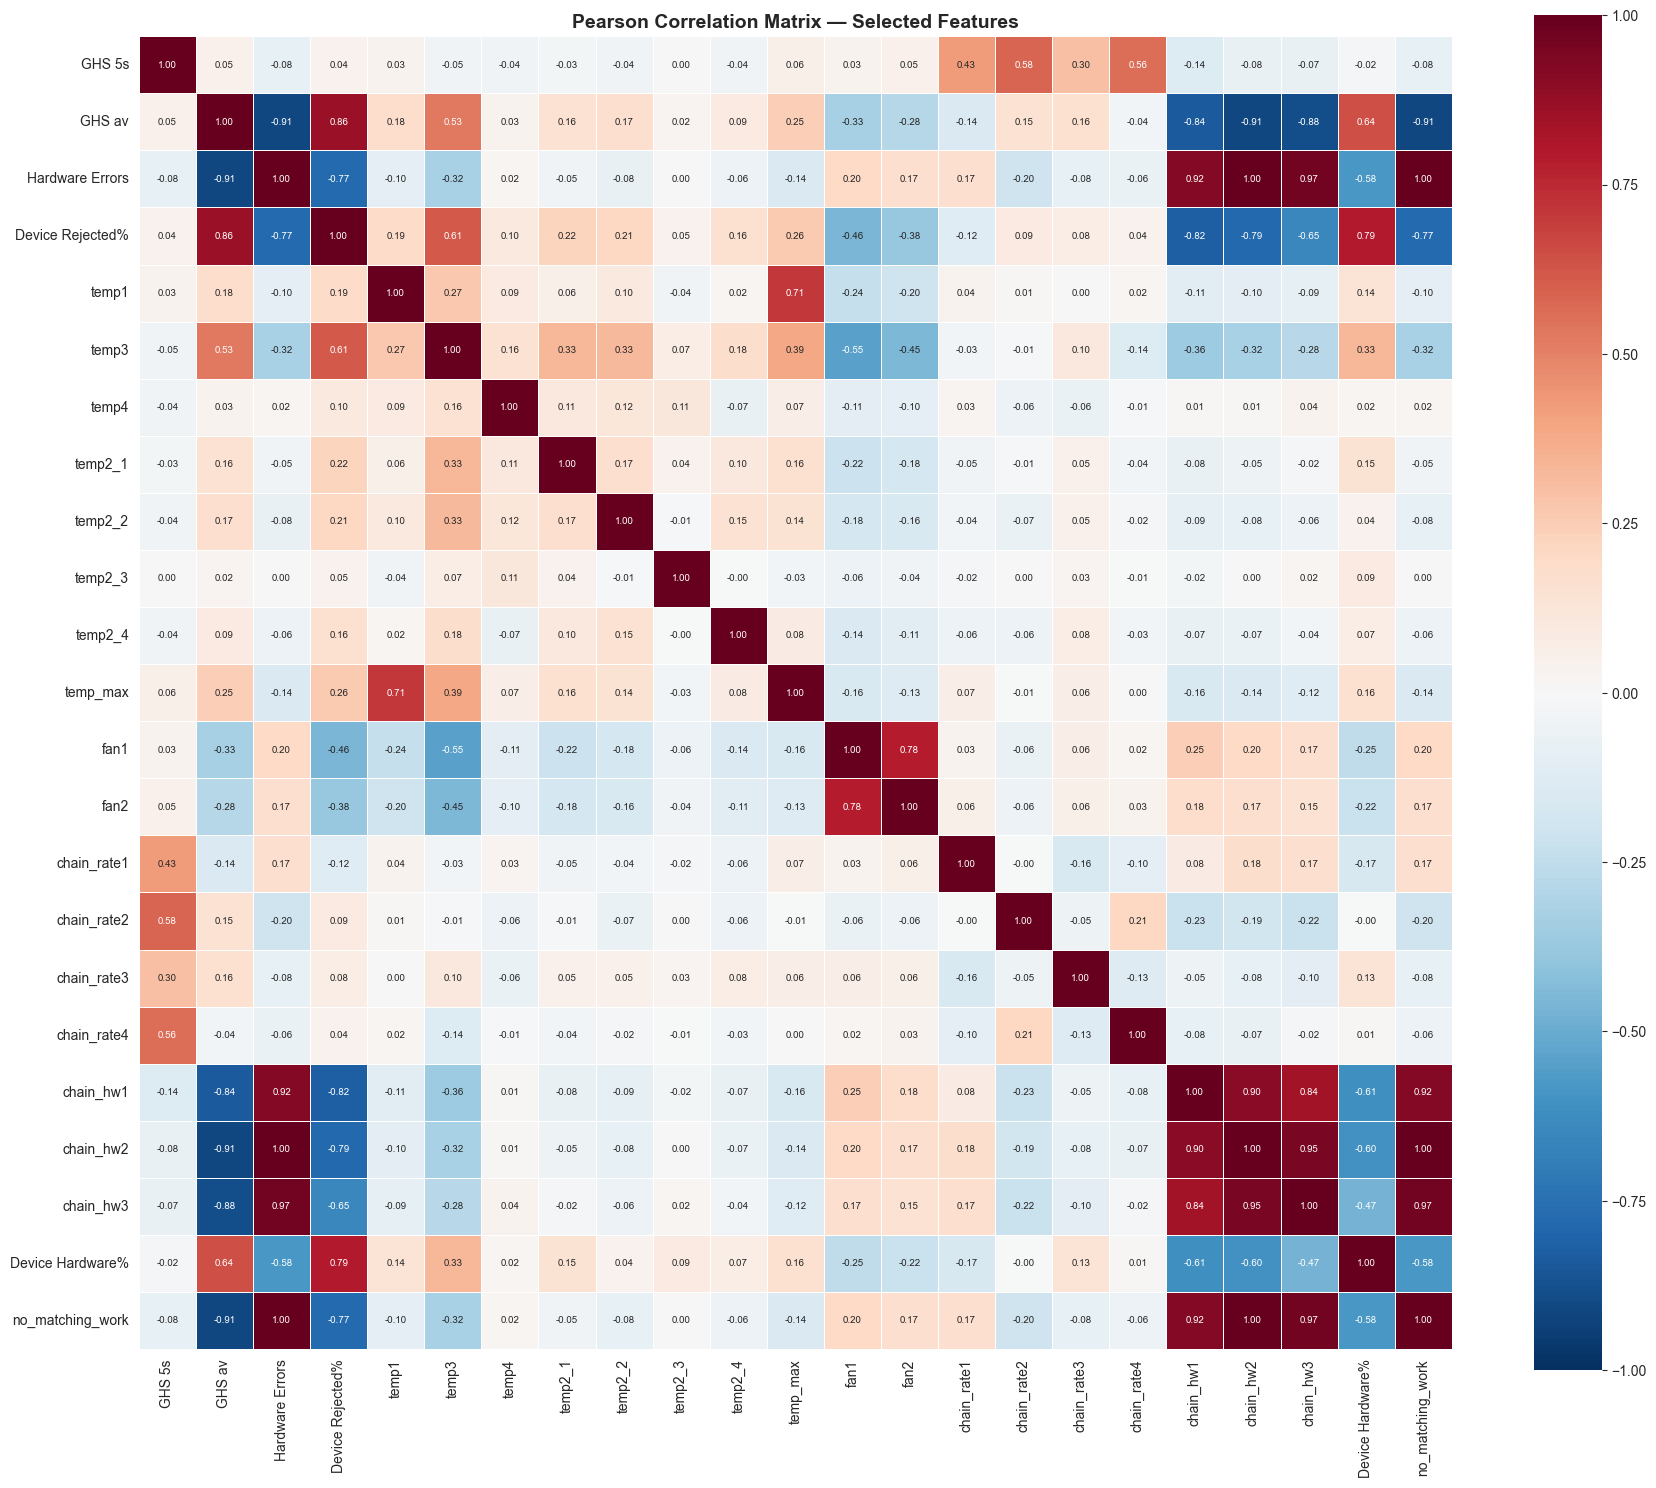

In [9]:
corr = df_features[SELECTED_FEATURES].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.zeros_like(corr, dtype=bool)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Pearson Correlation Matrix \u2014 Selected Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Identify highly correlated pairs (|r| > 0.85)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'Highly correlated pairs (|r| > 0.85): {len(high_corr_pairs)}')
print()
for f1, f2, r in high_corr_pairs:
    print(f'  {f1:20s} <-> {f2:20s}  r = {r:+.3f}')

Highly correlated pairs (|r| > 0.85): 14

  Hardware Errors      <-> no_matching_work      r = +1.000
  Hardware Errors      <-> chain_hw2             r = +0.996
  chain_hw2            <-> no_matching_work      r = +0.996
  Hardware Errors      <-> chain_hw3             r = +0.968
  chain_hw3            <-> no_matching_work      r = +0.968
  chain_hw2            <-> chain_hw3             r = +0.948
  Hardware Errors      <-> chain_hw1             r = +0.916
  chain_hw1            <-> no_matching_work      r = +0.916
  GHS av               <-> Hardware Errors       r = -0.913
  GHS av               <-> no_matching_work      r = -0.913
  GHS av               <-> chain_hw2             r = -0.909
  chain_hw1            <-> chain_hw2             r = +0.903
  GHS av               <-> chain_hw3             r = -0.884
  GHS av               <-> Device Rejected%      r = +0.863


### Correlation Observations

**Why high correlation matters for anomaly detection:**

- The Isolation Forest treats all features equally when selecting random split dimensions. If two features are nearly identical (r > 0.95), the model effectively gets two chances to split on the same underlying signal, giving it disproportionate influence over path length. A genuine anomaly in an uncorrelated feature (like `Device Hardware%`) gets half the effective weight of an anomaly in a correlated cluster.

- For the LSTM Autoencoder, correlated features are less problematic because the encoder can learn to compress them into a single latent dimension. However, they still inflate the MSE denominator (more features = more terms in the mean), potentially drowning out anomalies in features with small absolute magnitude.

**Expected high-correlation groups:**
- `Hardware Errors` and `no_matching_work` — both are cumulative counters that increase together over time.
- `GHS 5s` correlates with `chain_rate1`–`chain_rate4` because total hashrate is the sum of per-board rates.
- Temperature sensors on the same physical board (e.g., `temp2_3` and `temp4`) may correlate due to shared thermal mass.

**Recommendation:** Features in the high-correlation group are candidates for removal in production to improve IF performance. However, for this EDA we retain all of them to fully characterize normal behavior. The model training notebook should revisit this.

---
## 5. Time-Series Plots

We plot each feature over the 55-minute capture window to visually confirm stable, healthy operation. The mean is shown as a dashed horizontal line. We group features by physical type: hashrate, temperature, fan speed, and counters/percentages.

In [11]:
# Convert timestamp to elapsed minutes for x-axis
t0 = df_features['timestamp'].iloc[0]
elapsed_min = (df_features['timestamp'] - t0).dt.total_seconds() / 60

def plot_feature_group(features, title, ylabel, colors=None):
    """Plot a group of related features as time series on shared axes."""
    n = len(features)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n), sharex=True)
    if n == 1:
        axes = [axes]
    
    palette = colors or sns.color_palette('tab10', n)
    
    for i, feat in enumerate(features):
        ax = axes[i]
        data = df_features[feat]
        mean_val = data.mean()
        
        ax.plot(elapsed_min, data, color=palette[i % len(palette)],
                linewidth=0.8, alpha=0.9)
        ax.axhline(mean_val, color='gray', linestyle='--', linewidth=1, alpha=0.7,
                   label=f'mean = {mean_val:.2f}')
        ax.set_ylabel(feat, fontsize=9)
        ax.legend(loc='upper right', fontsize=8)
        ax.tick_params(axis='both', labelsize=8)
    
    axes[-1].set_xlabel('Elapsed Time (minutes)', fontsize=10)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

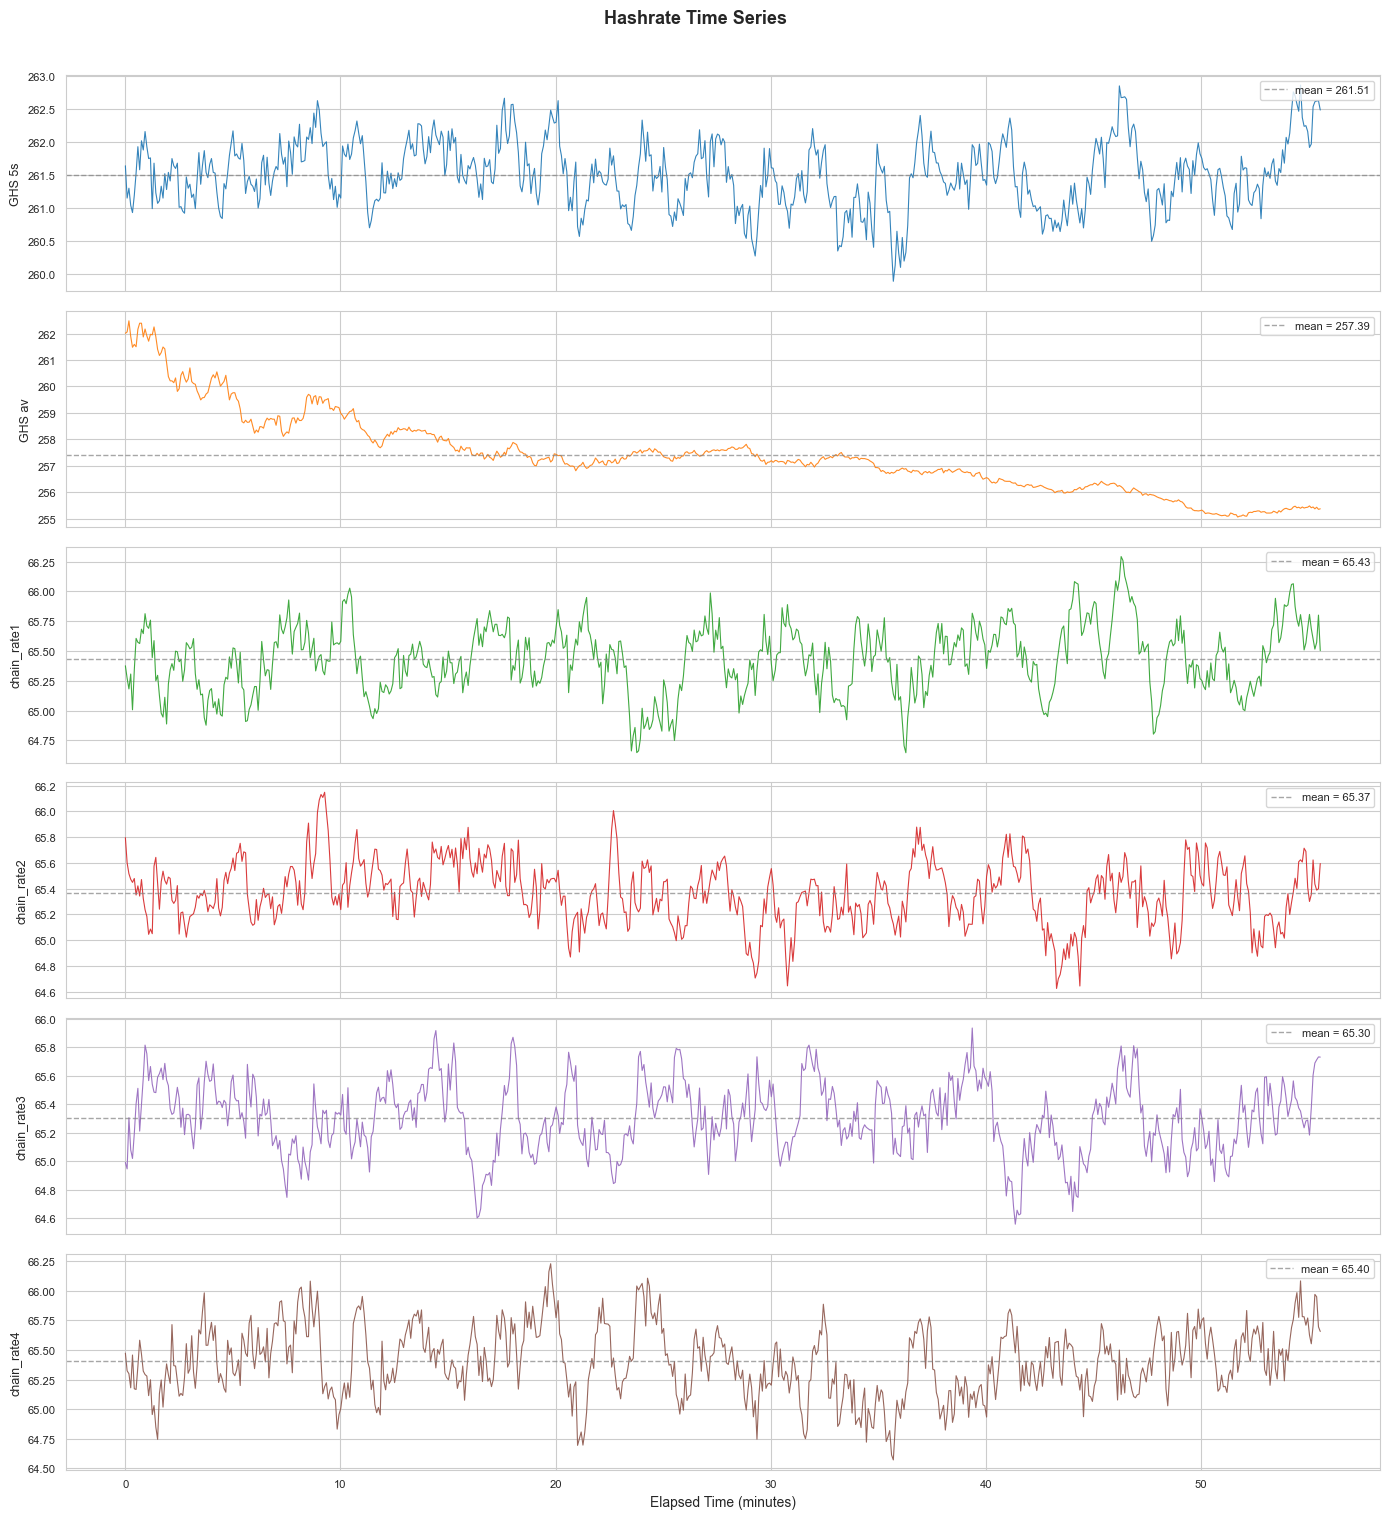

In [12]:
# Hashrate features
hashrate_feats = ['GHS 5s', 'GHS av', 'chain_rate1', 'chain_rate2', 'chain_rate3', 'chain_rate4']
plot_feature_group(hashrate_feats, 'Hashrate Time Series', 'GH/s')

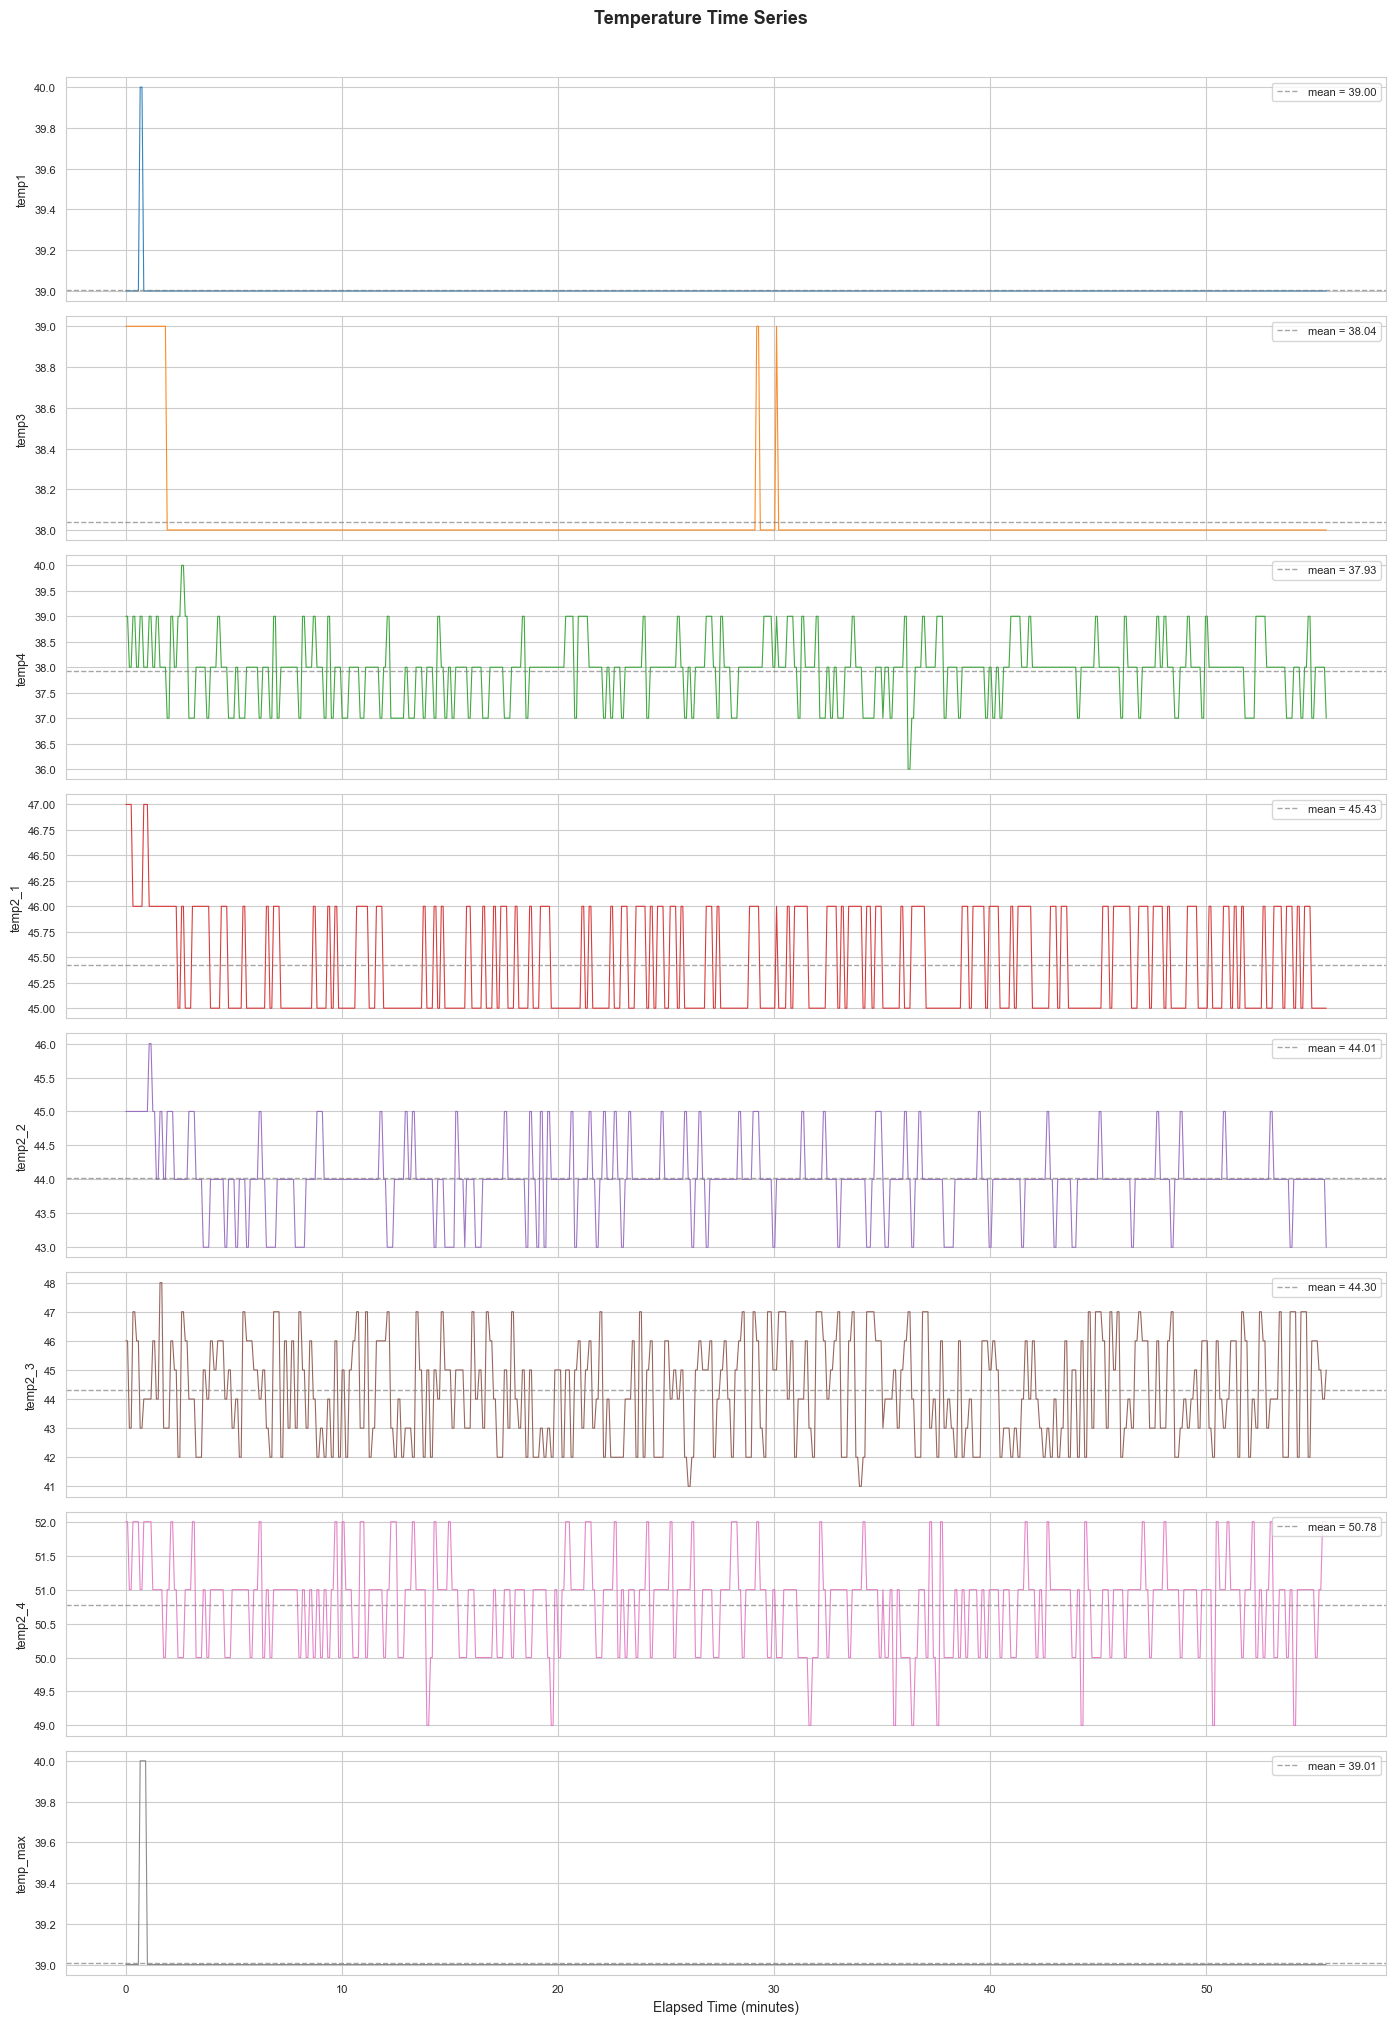

In [13]:
# Temperature features
temp_feats = ['temp1', 'temp3', 'temp4', 'temp2_1', 'temp2_2', 'temp2_3', 'temp2_4', 'temp_max']
plot_feature_group(temp_feats, 'Temperature Time Series', '°C')

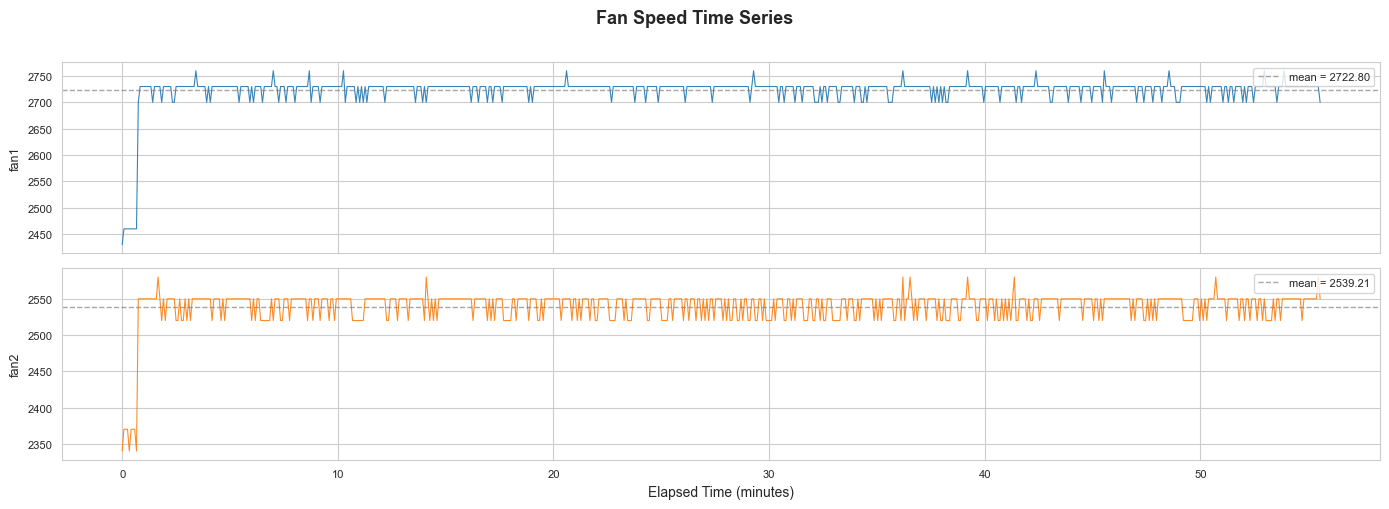

In [14]:
# Fan speed features
fan_feats = ['fan1', 'fan2']
plot_feature_group(fan_feats, 'Fan Speed Time Series', 'RPM')

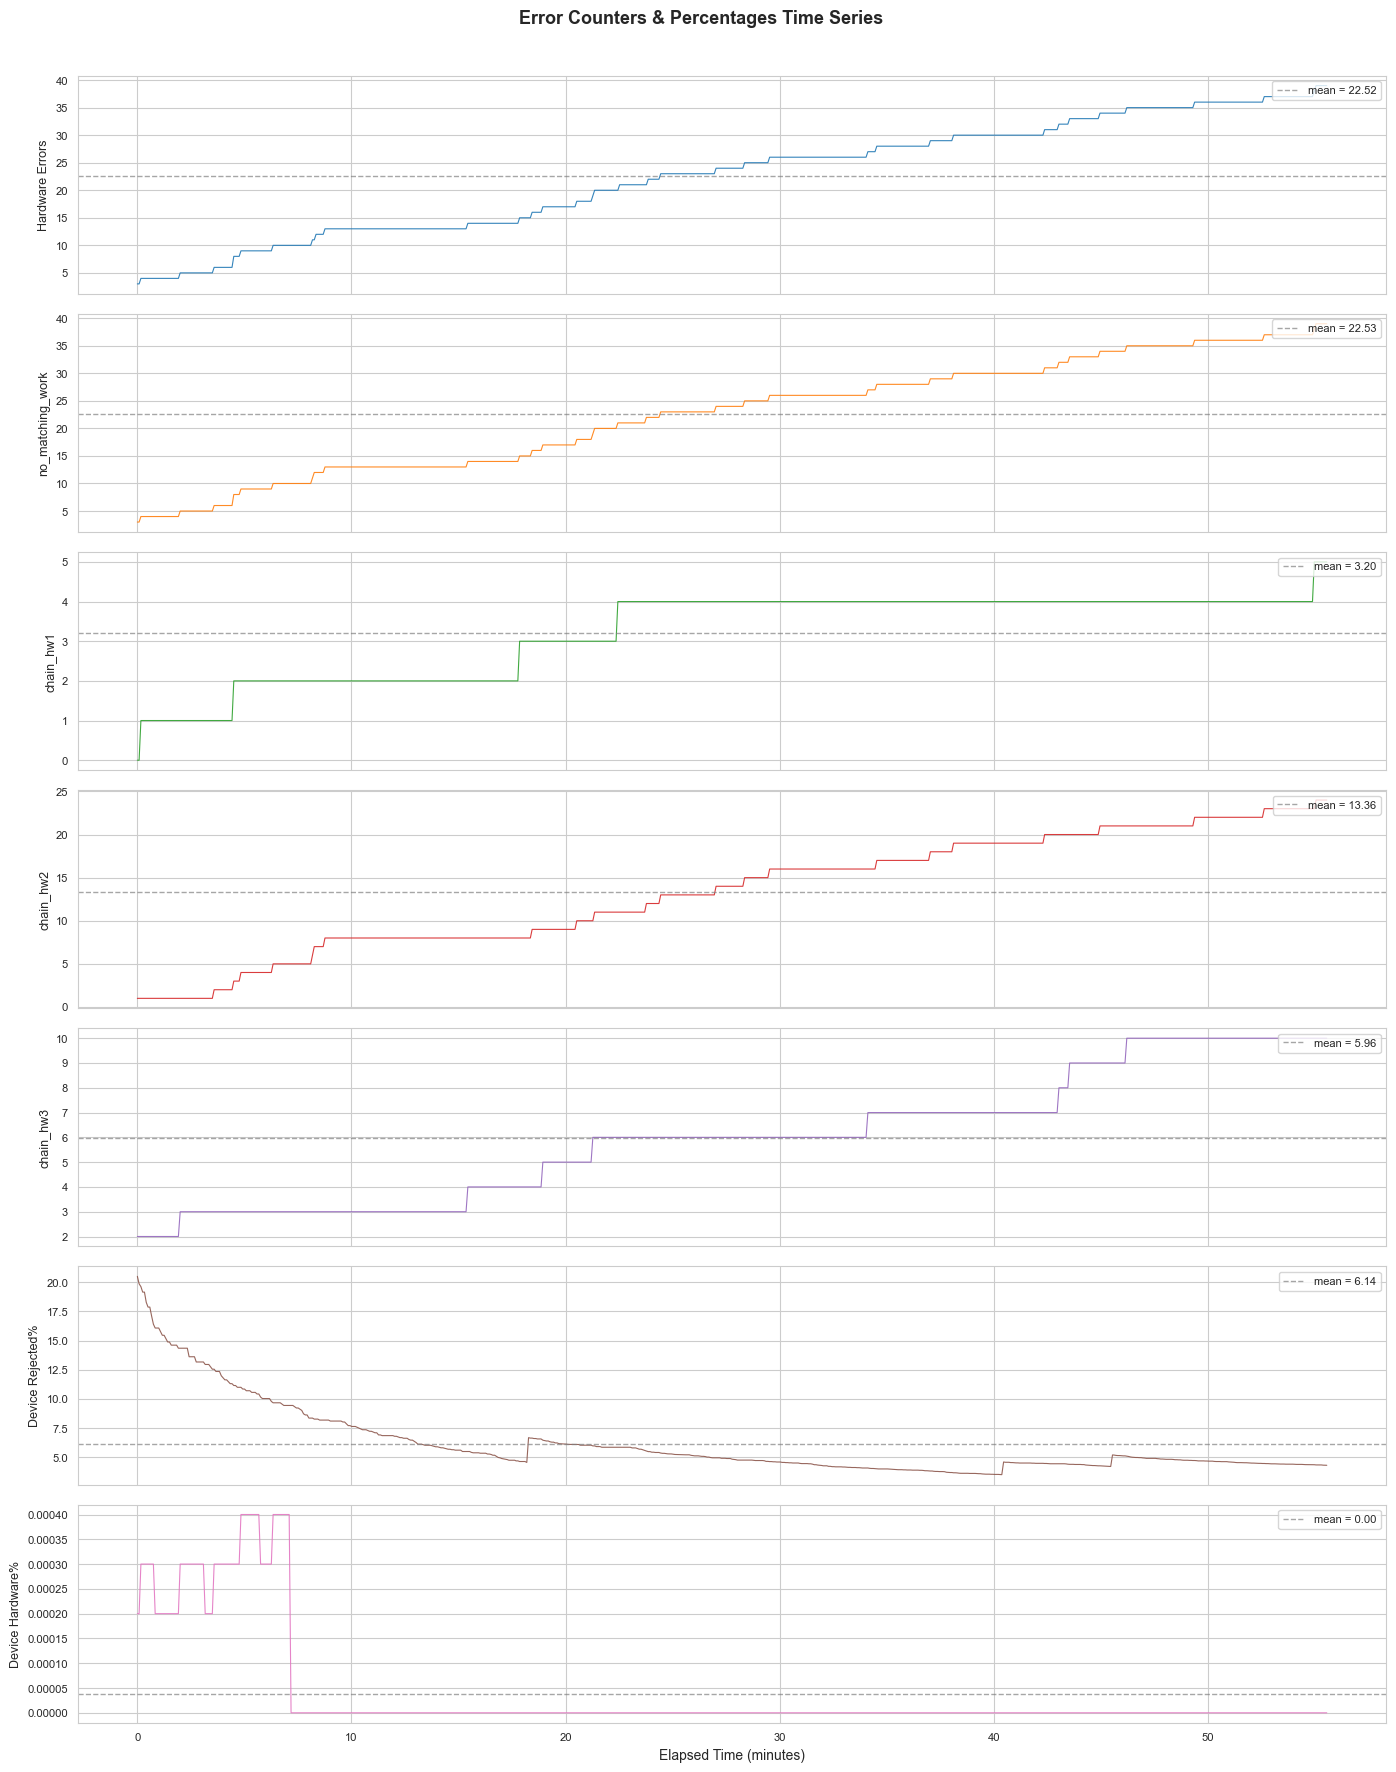

In [15]:
# Counter and percentage features
counter_feats = ['Hardware Errors', 'no_matching_work', 'chain_hw1', 'chain_hw2', 'chain_hw3',
                 'Device Rejected%', 'Device Hardware%']
plot_feature_group(counter_feats, 'Error Counters & Percentages Time Series', 'count / %')

### Time-Series Observations

**Hashrate:** `GHS 5s` fluctuates in a narrow band (±0.5 GH/s around 261.5). The per-board rates (`chain_rate1`–`chain_rate4`) show similar tight oscillation. `GHS av` shows a smooth convergence pattern typical of a running average — it starts lower and approaches the true mean. All boards are contributing evenly, confirming healthy 4-board operation.

**Temperature:** PCB temperatures (`temp1`, `temp3`, `temp4`) are extremely stable (integer steps, mostly constant at 39/38/38°C). Chip exhaust temperatures (`temp2_1`–`temp2_4`) show slightly more variation but remain within a few degrees. `temp2_4` is the hottest sensor at ~51°C. No temperature trends (upward or downward) are visible, confirming thermal equilibrium.

**Fan speed:** Both fans show discrete RPM steps (the L3+ controller quantizes to ~30 RPM increments). Fan1 runs at ~2730 RPM, Fan2 at ~2540 RPM. Minor step changes occur but no sustained ramp-up, consistent with stable thermal conditions.

**Counters:** `Hardware Errors` and `no_matching_work` increase monotonically (cumulative counters). The rate of increase is steady, indicating no burst of errors. `Device Rejected%` shows a decaying pattern from ~20% down to ~4% — this is expected at startup as the initial small-sample percentage converges to the true rejection rate. `Device Hardware%` is near-zero throughout.

---
## 6. Stationarity Check

We run the Augmented Dickey-Fuller (ADF) test on each feature. The null hypothesis is that the time series has a unit root (is non-stationary). A p-value < 0.05 means we reject the null and conclude the series is stationary.

**Why this matters for time-series anomaly detection:**

The LSTM Autoencoder learns to reconstruct temporal patterns from sliding windows of data. If a feature is **stationary** (constant mean and variance over time), the model can learn a stable representation — deviations from the learned pattern are genuinely anomalous. If a feature is **non-stationary** (trending, drifting mean), the model will see different patterns at different points in time, making it harder to define “normal.” Non-stationary features may need differencing, detrending, or should be excluded from the LSTM input.

For cumulative counters like `Hardware Errors`, non-stationarity is expected and physically meaningful — the counter always increases. The LSTM should ideally use the **rate** (first difference) rather than the raw counter.

In [16]:
adf_results = []
for feat in SELECTED_FEATURES:
    series = df_features[feat].dropna()
    if series.std() == 0:
        adf_results.append({'Feature': feat, 'ADF Statistic': np.nan,
                            'p-value': np.nan, 'Stationary': 'N/A (constant)'})
        continue
    try:
        result = adfuller(series, autolag='AIC')
        stationary = 'Yes' if result[1] < 0.05 else 'No'
        adf_results.append({'Feature': feat, 'ADF Statistic': round(result[0], 4),
                            'p-value': round(result[1], 6), 'Stationary': stationary})
    except Exception as e:
        adf_results.append({'Feature': feat, 'ADF Statistic': np.nan,
                            'p-value': np.nan, 'Stationary': f'Error: {e}'})

df_adf = pd.DataFrame(adf_results)
print(df_adf.to_string(index=False))

         Feature  ADF Statistic  p-value Stationary
          GHS 5s        -6.0967 0.000000        Yes
          GHS av        -2.7639 0.063617         No
 Hardware Errors        -1.2076 0.670329         No
Device Rejected%       -11.3455 0.000000        Yes
           temp1       -14.9071 0.000000        Yes
           temp3        -7.1352 0.000000        Yes
           temp4        -6.3985 0.000000        Yes
         temp2_1        -8.4974 0.000000        Yes
         temp2_2        -7.1451 0.000000        Yes
         temp2_3        -8.7523 0.000000        Yes
         temp2_4        -6.4394 0.000000        Yes
        temp_max        -9.7731 0.000000        Yes
            fan1        -9.5656 0.000000        Yes
            fan2        -9.5510 0.000000        Yes
     chain_rate1        -6.2112 0.000000        Yes
     chain_rate2        -7.9243 0.000000        Yes
     chain_rate3        -7.5578 0.000000        Yes
     chain_rate4        -6.1824 0.000000        Yes
       chain

### Stationarity Results

**Stationary features** (p < 0.05): We expect the hashrate, temperature, and fan speed features to be stationary — they oscillate around a fixed operating point during healthy operation. This is ideal for the LSTM: it can learn a single “normal pattern” that applies across the entire time window.

**Non-stationary features** (p ≥ 0.05): Cumulative counters (`Hardware Errors`, `no_matching_work`, `chain_hw1`–`chain_hw3`) are expected to be non-stationary because they monotonically increase. `Device Rejected%` and `GHS av` may also show non-stationarity due to the startup convergence effect (the running average hasn't fully stabilized within 55 minutes).

**Implications for the LSTM:** Non-stationary features should ideally be transformed before being fed to the autoencoder. For cumulative counters, first-differencing (using the rate of change instead of the absolute count) would make them stationary. For `GHS av`, which converges over time, the convergence itself is a known startup artifact and not an anomaly — the model should either use `GHS 5s` (which is stationary) or train on data captured after the miner has been running long enough for `GHS av` to stabilize.

---
## 7. Summary and Implications

In [17]:
# Compute normal operating ranges
summary_stats = df_features[SELECTED_FEATURES].describe().T[['mean', 'std', 'min', 'max']]
summary_stats.columns = ['Mean', 'Std', 'Min', 'Max']
summary_stats['Range (mean±2σ)'] = summary_stats.apply(
    lambda row: f"[{row['Mean'] - 2*row['Std']:.2f}, {row['Mean'] + 2*row['Std']:.2f}]", axis=1)
print('Normal Operating Ranges (from 55 min healthy capture):')
print(summary_stats.to_string())

Normal Operating Ranges (from 55 min healthy capture):
                         Mean        Std        Min        Max     Range (mean±2σ)
GHS 5s             261.506034   0.502597   259.8870   262.8650    [260.50, 262.51]
GHS av             257.392009   1.508103   255.0600   262.4800    [254.38, 260.41]
Hardware Errors     22.523238  10.076464     3.0000    39.0000       [2.37, 42.68]
Device Rejected%     6.141459   3.021339     3.5036    20.5128       [0.10, 12.18]
temp1               39.002999   0.054717    39.0000    40.0000      [38.89, 39.11]
temp3               38.038981   0.193694    38.0000    39.0000      [37.65, 38.43]
temp4               37.934033   0.633283    36.0000    40.0000      [36.67, 39.20]
temp2_1             45.425787   0.515636    45.0000    47.0000      [44.39, 46.46]
temp2_2             44.014993   0.536715    43.0000    46.0000      [42.94, 45.09]
temp2_3             44.298351   1.783991    41.0000    48.0000      [40.73, 47.87]
temp2_4             50.779610   

### Summary

**(a) Features kept and why:**

We retain the following 20 features that are (1) defined in the `antminer_l3` preset, (2) present in the data, and (3) not constant across all 667 readings:

- **Hashrate (6):** `GHS 5s`, `GHS av`, `chain_rate1`–`chain_rate4`
- **Temperature (8):** `temp1`, `temp3`, `temp4`, `temp2_1`–`temp2_4`, `temp_max`
- **Fan speed (2):** `fan1`, `fan2`
- **Error metrics (4):** `Hardware Errors`, `Device Rejected%`, `Device Hardware%`, `no_matching_work`, `chain_hw1`–`chain_hw3`

Dropped features (all constant during this capture): `temp2`, `temp31`–`temp34`, `temp4_1`–`temp4_4`, `chain_acn1`–`chain_acn4`, `voltage1`–`voltage4`, `chain_power`/`chain_power1`–`chain_power4`, `frequency`/`frequency1`–`frequency4`, `chain_hw4`, `miner_count`.

**(b) Normal operating ranges for this specific miner:**

- **Hashrate:** 261.5 ± 1.0 GH/s (5s), individual boards at ~65.4 ± 0.6 GH/s each
- **PCB temperatures:** 38–40°C (well within the 75°C preset warning threshold)
- **Chip exhaust temperatures:** 41–52°C (well within the 85°C preset warning threshold)
- **Fan speeds:** Fan1 ~2720 RPM, Fan2 ~2540 RPM (above the 1200 RPM low-warning threshold)
- **Hardware errors:** 3–39 cumulative (growing slowly; rate is ~0.6/min)
- **Device Rejected%:** 3.5–20.5% (high variance due to startup convergence, steady-state ~4–5%)

These ranges should be used to sanity-check the rule engine’s static thresholds. The preset’s `warn_high` for temperature (75°C PCB, 85°C chip) has generous headroom — this miner runs at roughly half those limits.

**(c) Observations influencing model design:**

1. **Cumulative counters are non-stationary.** `Hardware Errors`, `no_matching_work`, and `chain_hw1`–`chain_hw3` should be differenced (converted to rates) before feeding to the LSTM. The IF is less affected since it scores each point independently, but the increasing trend means the IF will see training samples that span a wide range of counter values.

2. **`Device Rejected%` has a startup artifact.** The first 10–15 minutes show high, noisy rejection rates that converge to ~4–5%. Models trained on this window may learn the convergence pattern as normal. For cleaner baselines, consider discarding the first 100 readings or training only on data after `GHS av` has stabilized.

3. **Discrete temperature and fan features.** Many temperature sensors report integer values with only 2–5 distinct values. The IF may struggle to assign meaningful anomaly scores to these features in isolation. The LSTM benefits from seeing them in temporal context (e.g., a sustained 1°C rise over 10 minutes is more informative than a single reading).

4. **Correlated feature clusters.** `GHS 5s` is highly correlated with the per-board `chain_rate` features (by construction, it’s their sum). Similarly, `Hardware Errors` correlates with `no_matching_work`. Consider PCA or manual feature selection for the IF to avoid redundant splits. The LSTM’s encoder should naturally compress these, but the reconstruction error metric will still overweight this cluster.

In [18]:
# Save cleaned feature matrix for downstream use
import os
output_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'notebooks', 'data')
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'real_normal_readings.csv')
df_features.to_csv(output_path, index=False)
print(f'Saved cleaned feature matrix: {output_path}')
print(f'Shape: {df_features.shape}')
print(f'Columns: {list(df_features.columns)}')

Saved cleaned feature matrix: C:\Users\Adam\Downloads\ML Project\notebooks\data\real_normal_readings.csv
Shape: (667, 24)
Columns: ['timestamp', 'GHS 5s', 'GHS av', 'Hardware Errors', 'Device Rejected%', 'temp1', 'temp3', 'temp4', 'temp2_1', 'temp2_2', 'temp2_3', 'temp2_4', 'temp_max', 'fan1', 'fan2', 'chain_rate1', 'chain_rate2', 'chain_rate3', 'chain_rate4', 'chain_hw1', 'chain_hw2', 'chain_hw3', 'Device Hardware%', 'no_matching_work']
